In [1]:
import os
import sys
from pathlib import Path
repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from opensim_pendulum import OpenSimPendulum


In [2]:
model = OpenSimPendulum()
model._use_gravity = False
model.initialize(0.0)

In [3]:
# viz = osim.VisualizerUtilities()
# viz.showModel(model.model)

In [4]:
t = 0.0
dt = 0.01
t_end = 1.0
t_vals = []
torque_vals = []
alpha_vals = []
omega_vals = []
q_vals = []

torque = 50

while t < t_end:
    if t < 0.25 * t_end:
        model.set_inputs({'torque': torque}, t=t)
    elif t > 0.25 * t_end and t < 0.75 * t_end:
        model.set_inputs({'torque': -torque}, t=t)
    else:
        model.set_inputs({'torque': torque}, t=t)
    model.do_step(t, dt)
    t_vals.append(t)
    q = model.get_outputs()['q']
    q_vals.append(q)
    torque_vals.append(torque)
    omega = model.get_outputs()['omega']
    omega_vals.append(omega)
    alpha = model.get_outputs()['alpha']
    alpha_vals.append(alpha)
    t += dt

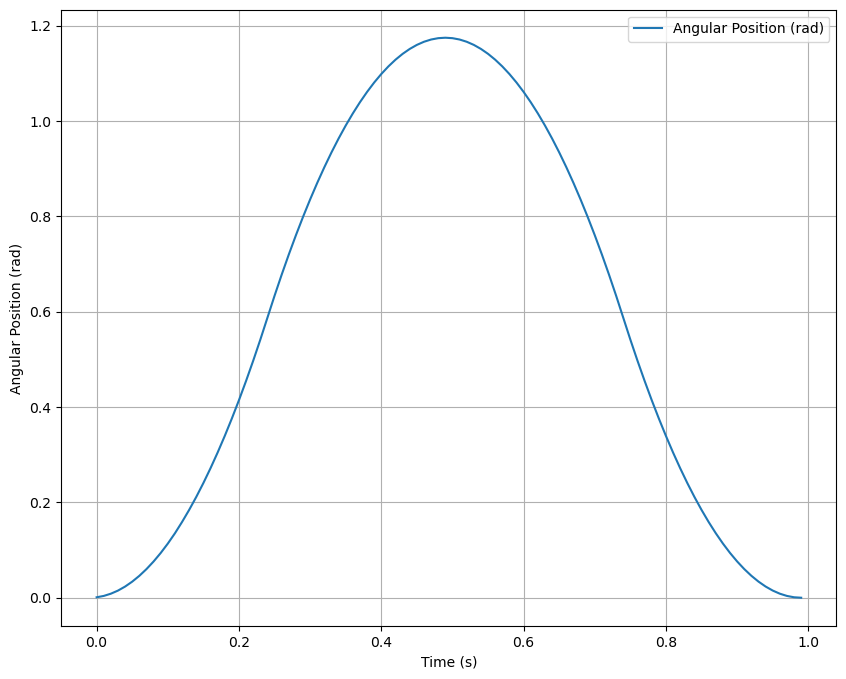

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.plot(t_vals, q_vals, label='Angular Position (rad)')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (rad)')
plt.grid()
plt.legend()
plt.show()

In [6]:
print(q_vals[-1])

-1.997509325402432e-14 rad


In [7]:
model.coord.getAccelerationValue(model.state)

18.796992481203002